In [5]:
! pip install matplotlib

  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl (234 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 13.0 MB/s eta 0:00:00
Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl (70 kB)
Using cached pyparsing-3.3.3-py3-none-any.whl (126 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import tensorflow as tf
import matplotlib.pyplot as  plt

In [10]:
import os

In [11]:
current_directory=os.getcwd()
train_path=os.path.join (current_directory,"data","Training")
valid_path=os.path.join( current_directory,"data","Validation")
test_path=os.path.join(current_directory,"data","Testing")

In [12]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    interpolation="bilinear",
)

Found 3251 files belonging to 3 classes.


In [14]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    interpolation="bilinear",
)

Found 416 files belonging to 3 classes.


In [15]:
cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))

cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))
cnn.add(tf.keras.layers.Dropout(0.4))

cnn.add(tf.keras.layers.Dense(units=3,activation='softmax'))

c:\Users\SHRIYA A\OneDrive\Documents\AICW\plant_leaf_disease_detection\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])


In [22]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         4,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,790,227 (29.72 MB)

 Trainable params: 7,790,227 (29.72 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 106s 975ms/step - accuracy: 0.5161 - loss: 0.9980 - val_accuracy: 0.6995 - val_loss: 0.7724
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 98s 959ms/step - accuracy: 0.6838 - loss: 0.7455 - val_accuracy: 0.7548 - val_loss: 0.5776
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.8025 - loss: 0.5211 - val_accuracy: 0.8389 - val_loss: 0.3968
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.8533 - loss: 0.3889 - val_accuracy: 0.8534 - val_loss: 0.3478
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.8957 - loss: 0.2962 - val_accuracy: 0.8798 - val_loss: 0.3034
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9191 - loss: 0.2415 - val_accuracy: 0.9062 - val_loss: 0.2299
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9277 - loss: 0.2049 - val_accuracy: 0.9399 - val_loss: 0.1746
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9542 - loss: 0.1344 - val

In [24]:
val_loss, val_acc = cnn.evaluate(validation_set)
print('validation accuracy', val_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.9135 - loss: 0.2094
validation accuracy 0.9134615659713745


In [25]:
cnn.save('trained_plant_disease_model.keras')

In [26]:
training_history.history

{'accuracy': [0.5161488652229309,
  0.6837896108627319,
  0.8025223016738892,
  0.8532758951187134,
  0.8957244157791138,
  0.9191018342971802,
  0.9277145266532898,
  0.9541679620742798,
  0.9446324110031128,
  0.968317449092865],
 'loss': [0.9980449080467224,
  0.7454847693443298,
  0.521095871925354,
  0.3888530731201172,
  0.2961541414260864,
  0.24148237705230713,
  0.20494069159030914,
  0.13440825045108795,
  0.14604750275611877,
  0.10282120108604431],
 'val_accuracy': [0.6995192170143127,
  0.754807710647583,
  0.838942289352417,
  0.8533653616905212,
  0.879807710647583,
  0.90625,
  0.9399038553237915,
  0.9350961446762085,
  0.9038461446762085,
  0.9134615659713745],
 'val_loss': [0.7724460363388062,
  0.5776197910308838,
  0.39683040976524353,
  0.3477812111377716,
  0.303390234708786,
  0.22993573546409607,
  0.17460881173610687,
  0.17591768503189087,
  0.29144400358200073,
  0.20940138399600983]}

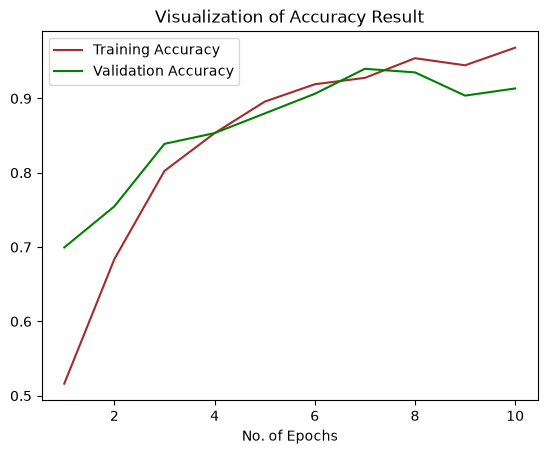

In [27]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='brown',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='green',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()